## Coloured noise vs white noise for $N = 2$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

import random_growth_src.lib as lib

plt.style.use("../project_style.mplstyle")
%config InlineBackend.figure_format = 'retina'

## Run simulations

In [2]:
#Simulation settings
n_steps = int(5e4)
n_runs = int(2e4)
t_max = 500
dt = t_max/n_steps

#Model parameters
x0 = np.full(n_runs, np.log10(1))
M = 0.1

#White noise run
D_white = 10
sim_step_white = partial(lib.two_patch_x_white_noise_step, M=M, D=D_white)
results_x_white, results_t =  lib.run_simulation(x0, t_max, n_runs, n_steps, sim_step_white)

#Colored noise run
lamb = 1
D_coloured = 10
eta0 = np.full(n_runs, 0.0)

sim_step_coloured = partial(lib.two_patch_x_coloured_noise_step, M=M, D=D_coloured, lamb=lamb)
results_x_coloured, results_t =  lib.run_simulation(x0, t_max, n_runs, n_steps, sim_step_coloured, eta0=eta0)

## Figure 2)

### Figure 2a)

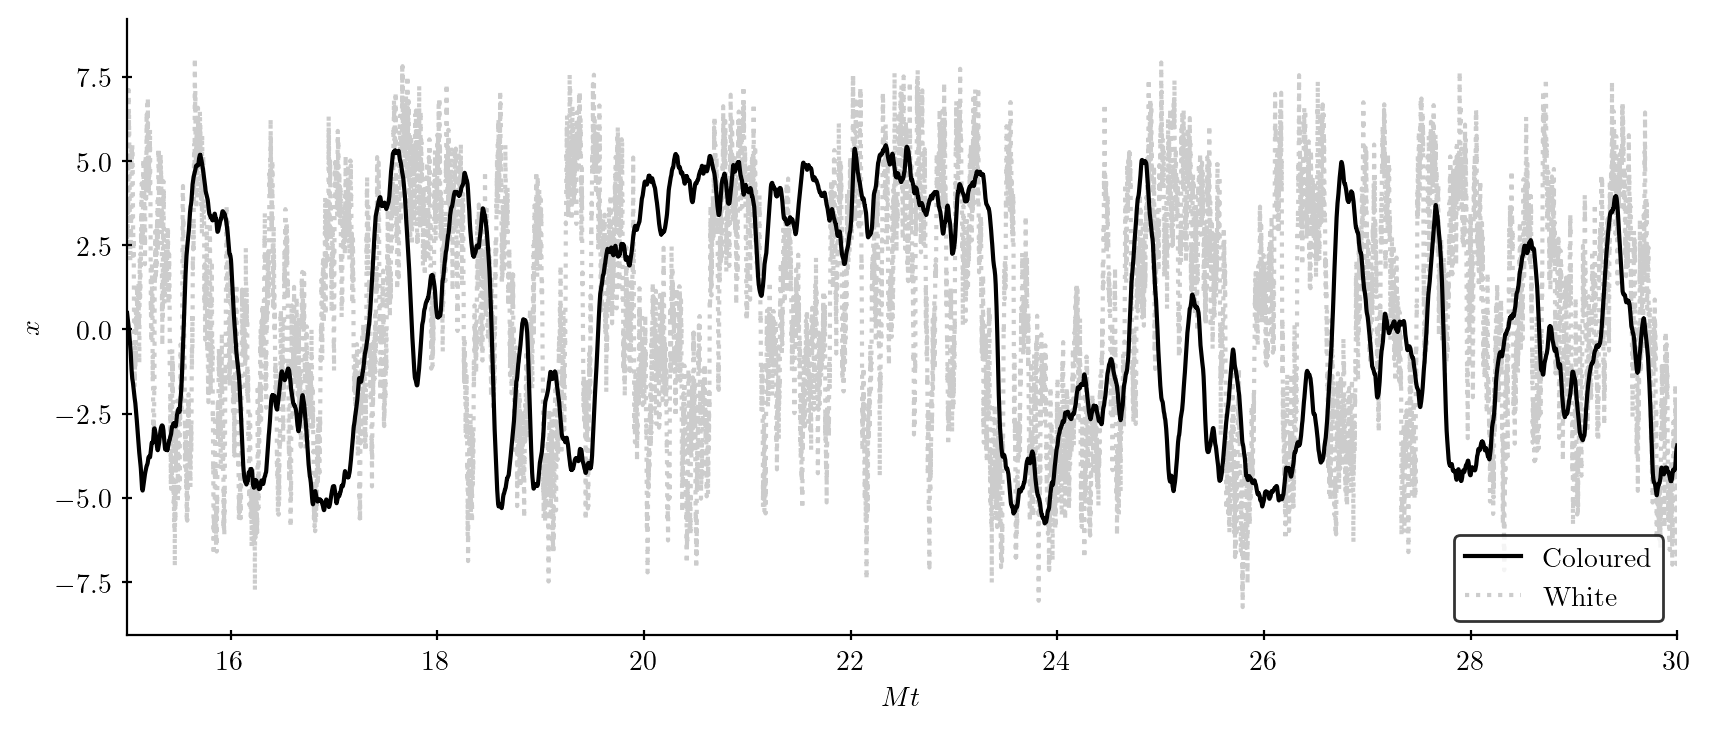

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(results_t * M, results_x_coloured[:, 100],  c='black', linestyle='-', label='Coloured')
ax.plot(results_t * M, results_x_white[:, 250],  c='black', linestyle=':', alpha=0.2, label='White')
ax.set_xlim([150 * M, 300 * M])
ax.set_xlabel('$M t$')
ax.set_ylabel('$x$')
ax.tick_params(axis='both')
ax.legend(edgecolor='black')
plt.savefig('../figures/fig_2a.svg', bbox_inches='tight', dpi=200, transparent=True);

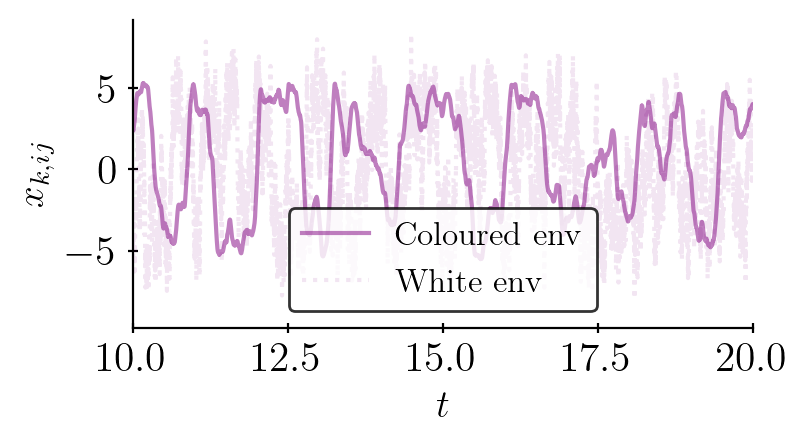

In [44]:
fig, ax = plt.subplots(figsize=(4, 2))
ax.plot(results_t * M, results_x_coloured[:, 30],  c='purple', alpha=0.5, label='Coloured env')
ax.plot(results_t * M, results_x_white[:, 30],  c='purple', alpha=0.1, linestyle=':', label='White env')
ax.set_xlim([100 * M, 200 * M])
ax.set_xlabel('$t$')
ax.set_ylabel(r'$x_{k,ij}$')
ax.tick_params(axis='both')
ax.legend(edgecolor='black')
plt.savefig('../figures/graphical_abstract_panel.svg', bbox_inches='tight', dpi=200, transparent=True);

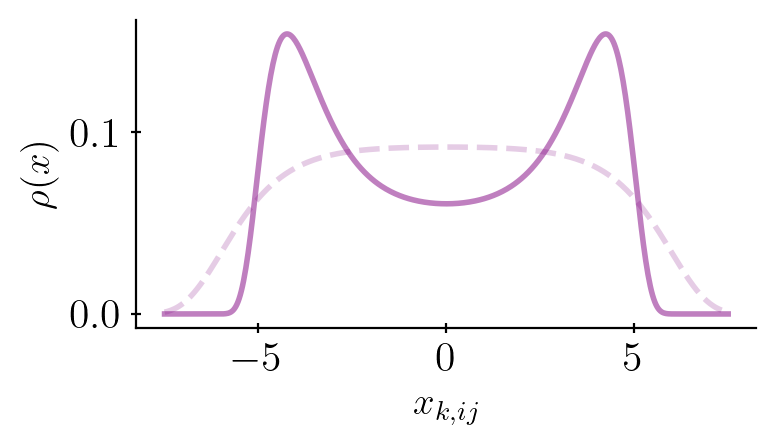

In [48]:
t_eval = 200 
x_vals = np.linspace(-7.5, 7.5, 500)

fig, ax = plt.subplots(figsize=(4, 2), sharey=True, sharex=True)

ax.plot(x_vals, lib.two_patch_steady_state_density_x_white_noise(x_vals, M=M, D=D_white), linewidth=2.0, c='purple', alpha=0.2, linestyle='--')
ax.plot(x_vals, lib.two_patch_steady_state_density_x_coloured_noise(x_vals, M=M, D=D_coloured, lamb=lamb), linewidth=2.0, c='purple', alpha=0.5)
ax.set_ylabel(r"$\rho(x)$")
ax.set_xlabel(r"$x_{k,ij}$")
plt.savefig('../figures/graphical_abstract_panel_2.svg', bbox_inches='tight', dpi=200, transparent=True);

### Figure 2b)

tM = 20.0


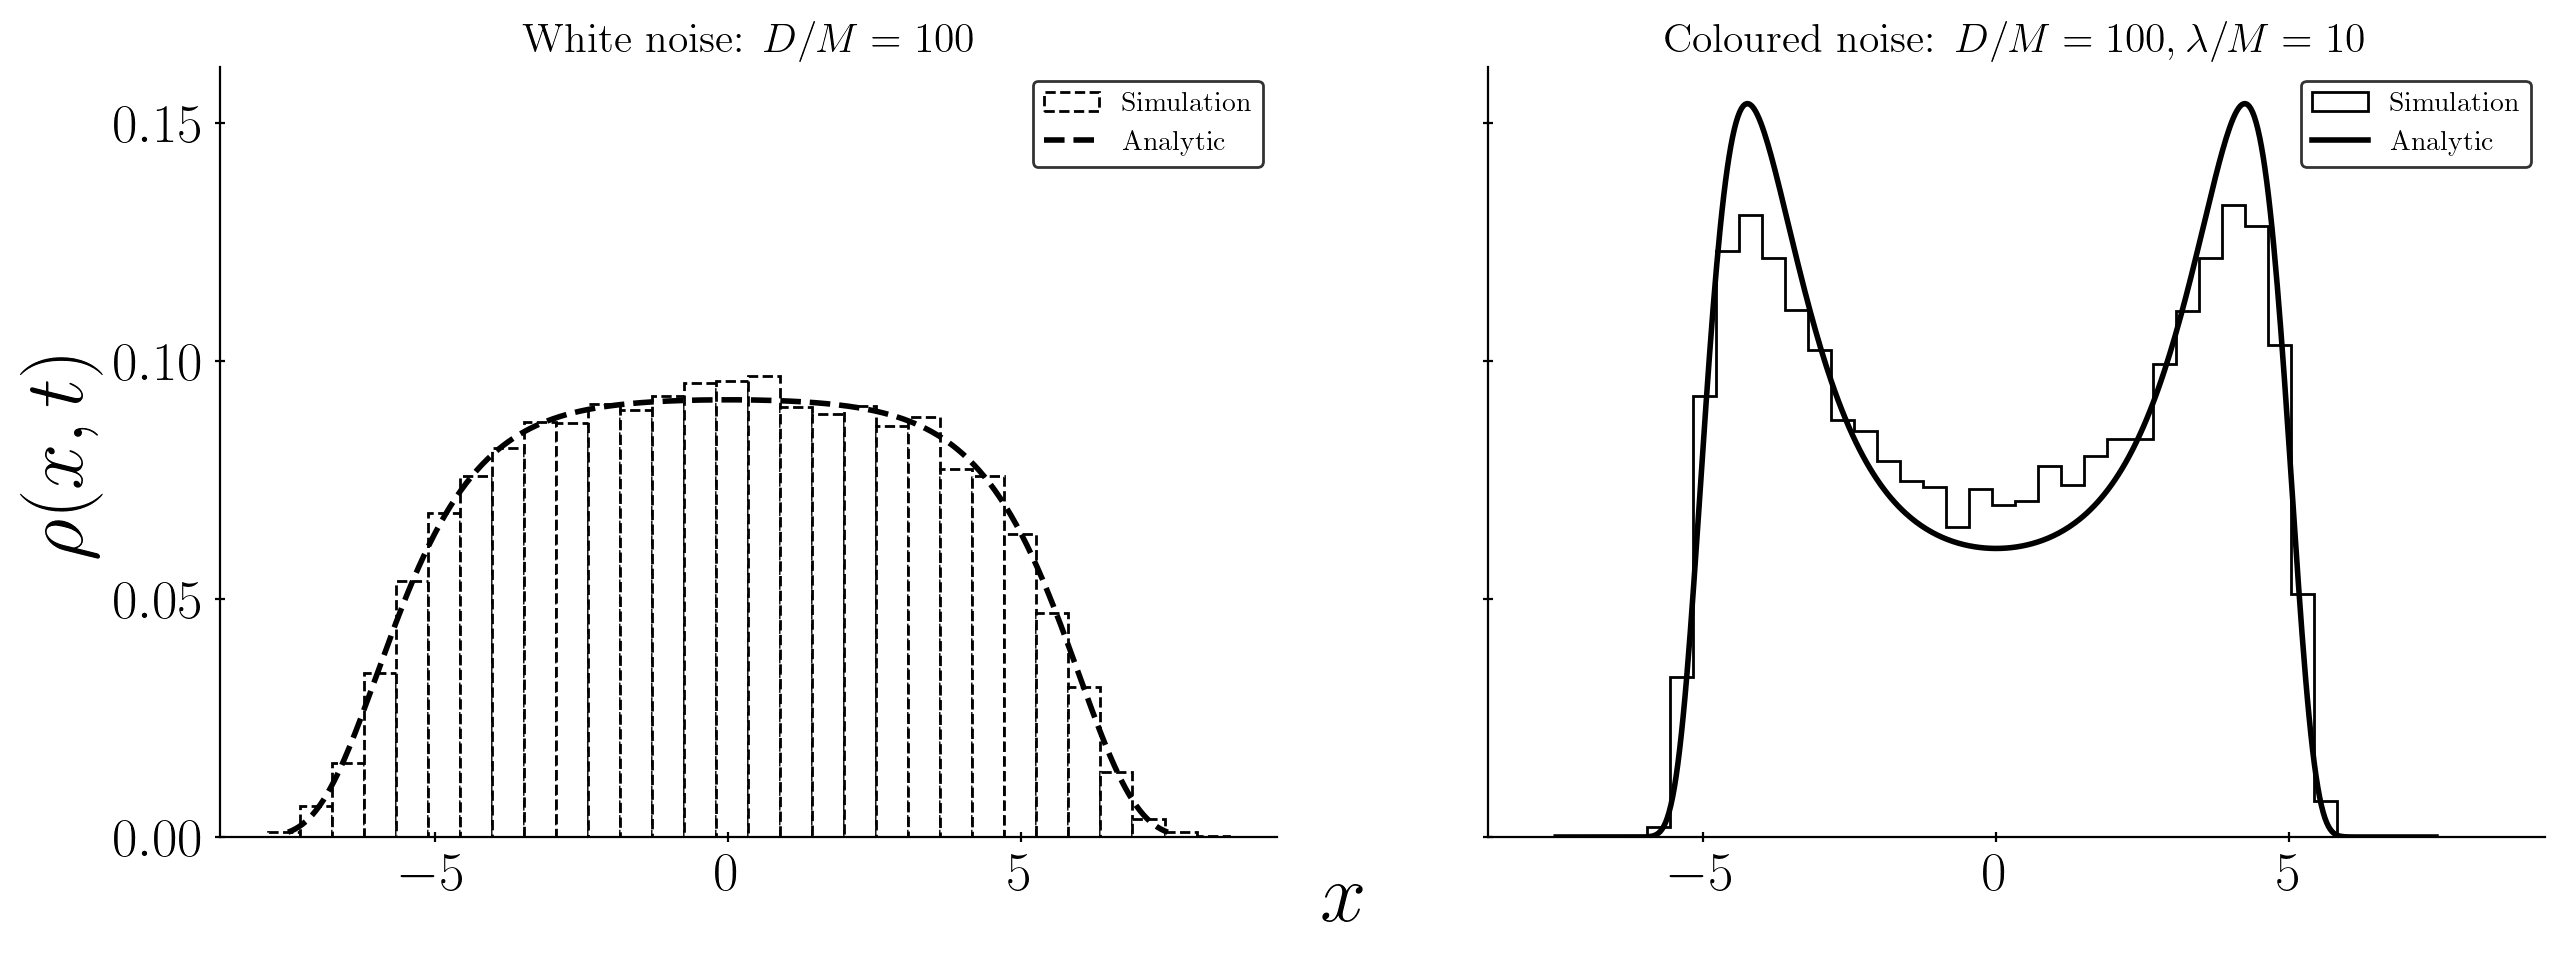

In [4]:
t_eval = 200 
x_vals = np.linspace(-7.5, 7.5, 500)
print(f"tM = {t_eval * M}")

fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True, sharex=True)

ax[0].hist(results_x_white[int(t_eval/dt)], bins=30, density=True, color='white', edgecolor='black', linestyle='--', linewidth=1, label='Simulation')
ax[0].plot(x_vals, lib.two_patch_steady_state_density_x_white_noise(x_vals, M=M, D=D_white), linewidth=2.0, c='black', alpha=1, linestyle='--', label='Analytic')
ax[0].legend(edgecolor='black', loc='upper right')
ax[0].set_title(rf"White noise: $D/M  = {D_white/M:.0f}$", fontsize=15)
ax[0].set_ylabel("$\\rho(x, t)$", fontsize=30)

ax[1].hist(results_x_coloured[int(t_eval/dt)], bins=30, density=True, color='white', edgecolor='black', histtype='step', label='Simulation') 
ax[1].plot(x_vals, lib.two_patch_steady_state_density_x_coloured_noise(x_vals, M=M, D=D_coloured, lamb=lamb), linewidth=2.0, c='black', alpha=1, label='Analytic')
ax[1].legend(edgecolor='black', loc='upper right')
ax[1].set_title(rf"Coloured noise: $D/M = {D_coloured/M:.0f}, \lambda/M = {lamb/M:.0f}$", fontsize=15)

ax[0].tick_params(axis='both', labelsize=20)
ax[1].tick_params(axis='both', labelsize=20)
ax[1].legend(edgecolor='black')

fig.supxlabel("$x$", fontsize=30)
plt.savefig('../figures/fig_2b.svg', bbox_inches='tight', dpi=200, transparent=True);

### Figure 2c)

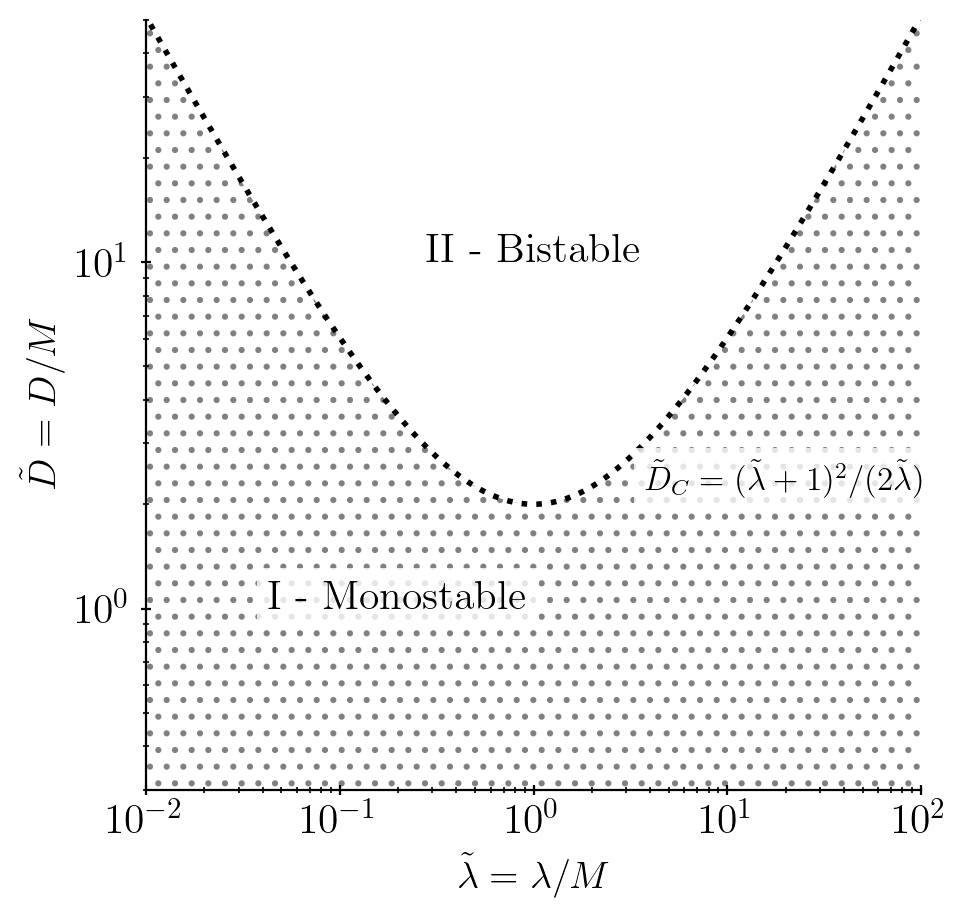

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))

lamb_tilde = np.logspace(-3, 3, 1000)
D_crit = (lamb_tilde  + 1)**2 / (2 * lamb_tilde )

ax.plot(lamb_tilde, D_crit, 'k:', linewidth=2)
ax.fill_between(lamb_tilde, 0, D_crit, hatch='..', facecolor='white', edgecolor='gray', linewidth=0)

ax.set_xlabel(r'$\tilde{\lambda} = \lambda/M$')
ax.set_ylabel(r'$\tilde{D} = D/M$')
ax.set_xlim(0.01, 100)
ax.set_ylim(0.3, 50)
ax.set_xscale('log')
ax.set_yscale('log')
# 
ax.text(1, 10, "II - Bistable", fontsize=15, weight='bold', c='black', ha='center',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))
ax.text(0.2, 1, "I - Monostable", fontsize=15, weight='bold', c='black', ha='center',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))
ax.text(20, 2.2, r"$\tilde{D}_C = (\tilde{\lambda} + 1)^2 / (2 \tilde{\lambda})$", fontsize=12, weight='bold', c='black', ha='center',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.8));
plt.savefig('../figures/fig_2c.svg', bbox_inches='tight', dpi=200, transparent=True);

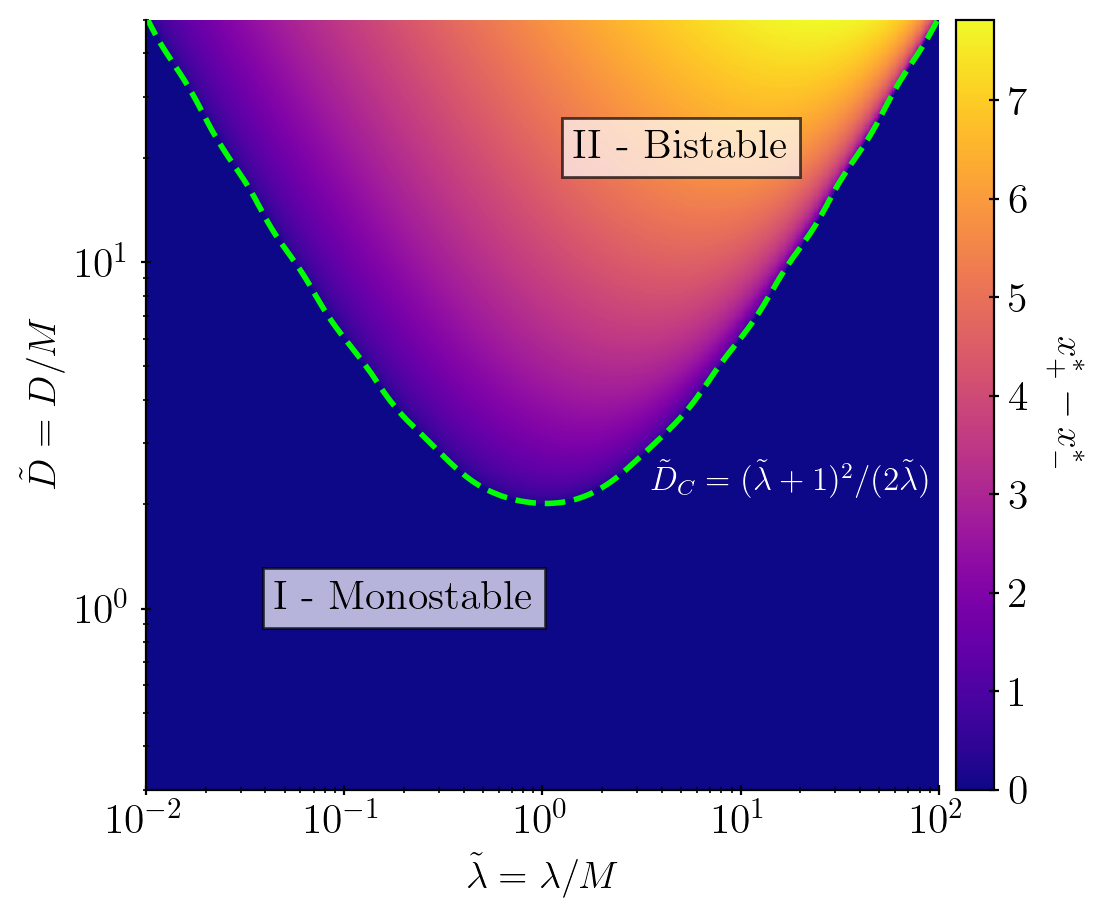

In [64]:
fig, ax = plt.subplots(figsize=(5.5, 5))

# --- domain for plotting (match your axis limits) ---
lam_min, lam_max = 0.01, 100
D_min, D_max = 0.3, 50

# 1D lambda grid for the critical line + line overlay
lamb_tilde = np.logspace(np.log10(lam_min), np.log10(lam_max), 1200)
D_crit = (lamb_tilde + 1)**2 / (2 * lamb_tilde)

# 2D grid for heatmap in log space (so the raster looks uniform on log axes)
n_lam, n_D = 700, 700
lam_edges = np.logspace(np.log10(lam_min), np.log10(lam_max), n_lam + 1)
D_edges   = np.logspace(np.log10(D_min),  np.log10(D_max),  n_D + 1)

lam_cent = np.sqrt(lam_edges[:-1] * lam_edges[1:])
D_cent   = np.sqrt(D_edges[:-1]   * D_edges[1:])

LAM, DD = np.meshgrid(lam_cent, D_cent)  # shape (n_D, n_lam)

# --- distance between peaks ---
# distance = arcosh( sqrt(2 D λ) - λ ), defined only when argument >= 1.
arg = np.sqrt(2.0 * DD * LAM) - LAM

# Apply your "set to zero below critical line" rule (also protects invalid arcosh)
Dcrit_grid = (LAM + 1.0)**2 / (2.0 * LAM)
mask_below = DD < Dcrit_grid

distance = np.zeros_like(arg)
mask_valid = (~mask_below) & (arg >= 1.0)
distance[mask_valid] = 2 * np.arccosh(arg[mask_valid])


hm = ax.pcolormesh(
    lam_edges, D_edges, distance,
    shading="auto",
    cmap="plasma",
)

# --- critical line (cyan) ---
line, = ax.plot(lamb_tilde, D_crit, color="lime", linestyle="--", linewidth=2)
line.set_sketch_params(scale=1.0, length=120.0, randomness=2.0)

# --- labels / limits / scales ---
ax.set_xlabel(r'$\tilde{\lambda} = \lambda/M$')
ax.set_ylabel(r'$\tilde{D} = D/M$')
ax.set_xlim(lam_min, lam_max)
ax.set_ylim(D_min, D_max)
ax.set_xscale('log')
ax.set_yscale('log')

# --- annotations (keep yours) ---
ax.text(5, 20, "II - Bistable", fontsize=15, weight='bold', c='black', ha='center', 
        bbox=dict(facecolor='white', edgecolor='black', alpha=0.7))
ax.text(0.2, 1, "I - Monostable", fontsize=15, weight='bold', c='black', ha='center',
        bbox=dict(facecolor='white', edgecolor='black', alpha=0.7))
ax.text(18, 2.2, r"$\tilde{D}_C = (\tilde{\lambda} + 1)^2 / (2 \tilde{\lambda})$",
        fontsize=12, weight='bold', c='white', ha='center')

cbar = fig.colorbar(hm, ax=ax, pad=0.02, fraction=0.05)
cbar.set_label(r'$x^{*}_{+} - x^{*}_{-}$', rotation=-90, labelpad=20.0)

# plt.savefig('../figures/fig_2c.svg', bbox_inches='tight', dpi=200, transparent=True);